In [72]:
import pandas as pd
print("Hello, IELE756!")
print(f"pandas version: {pd.__version__}")

Hello, IELE756!
pandas version: 2.2.2


# Tarea 0 --- IELE756
**Integrantes**: Roberto Verdejo , Mateo Estay



**Región**: Región Metropolitana


**Fecha**: 15/03/2026

## **1. Censo 2024**

1.1

In [2]:
import pandas as pd

ruta = "/content/drive/MyDrive/Colab Notebooks/personas_censo2024.csv"

persona = pd.read_csv(
    ruta,
    sep=';',
    encoding='latin-1',
    usecols=["region", "comuna", "sexo", "edad", "p27_nacionalidad",
             "p27_nacionalidad_rec", "escolaridad", "sit_fuerza_trabajo"]
)

persona.head()

,region,comuna,sexo,edad,p27_nacionalidad,p27_nacionalidad_rec,escolaridad,sit_fuerza_trabajo
0,5,5802,2,80,1,1,17,3.0
1,5,5802,1,52,1,1,14,1.0
2,5,5802,2,45,1,1,12,1.0
3,5,5802,2,8,1,1,2,NaN
4,4,4303,1,69,1,1,12,3.0


1.2

In [3]:
print(f"Total personas: {len(persona):,}")
print(persona.dtypes)


Total personas: 18,480,432
region                    int64
comuna                    int64
sexo                      int64
edad                      int64
p27_nacionalidad          int64
p27_nacionalidad_rec      int64
escolaridad               int64
sit_fuerza_trabajo      float64
dtype: object


In [4]:
print(persona.shape)
persona.head(10)

(18480432, 8)


,region,comuna,sexo,edad,p27_nacionalidad,p27_nacionalidad_rec,escolaridad,sit_fuerza_trabajo
0,5,5802,2,80,1,1,17,3.0
1,5,5802,1,52,1,1,14,1.0
2,5,5802,2,45,1,1,12,1.0
3,5,5802,2,8,1,1,2,NaN
4,4,4303,1,69,1,1,12,3.0
5,4,4303,2,65,1,1,12,3.0
6,4,4303,1,58,1,1,15,1.0
7,11,11202,2,-66,-66,1,8,1.0
8,11,11202,1,-66,-66,1,5,1.0
9,11,11202,1,-66,-66,1,3,NaN


In [5]:
persona.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18480432 entries, 0 to 18480431
Data columns (total 8 columns):
 #   Column                Dtype  
---  ------                -----  
 0   region                int64  
 1   comuna                int64  
 2   sexo                  int64  
 3   edad                  int64  
 4   p27_nacionalidad      int64  
 5   p27_nacionalidad_rec  int64  
 6   escolaridad           int64  
 7   sit_fuerza_trabajo    float64
dtypes: float64(1), int64(7)
memory usage: 1.1 GB


1.3 Región

In [10]:
regiones_unicas = persona['region'].unique()
print(regiones_unicas)

[ 5  4 11  1  8 13 14  9  7 10  3 12  2  6 16 15]


In [26]:
Metropolitana = persona[persona["region"] == 13]
print(f"Metropolitana: {len(Metropolitana):,} personas")

Metropolitana: 7,400,741 personas


1.4 Nacionalidad


In [27]:
# Códigos: 1=Chileno, 2=Chileno+otra, 3=Extranjero, -99=NR
print(Metropolitana["p27_nacionalidad"].value_counts())

p27_nacionalidad
 1     6303954
 3      904819
 2      142667
-99      49301
Name: count, dtype: int64


In [28]:
# Variable recodificada (más conveniente)
print(Metropolitana["p27_nacionalidad_rec"].value_counts())
foreign = Metropolitana["p27_nacionalidad_rec"] \
.value_counts(normalize=True)
print(f"% extranjeros: {foreign.get('Extranjero', 0):.1%}")

p27_nacionalidad_rec
 1     6446621
 2      904819
-99      49301
Name: count, dtype: int64
% extranjeros: 0.0%


# **2. ENO**

2.1 Load


In [34]:
ruta_eno = "/content/drive/MyDrive/Colab Notebooks/20241218_base_eno_final.csv"

eno = pd.read_csv(
    ruta_eno,
    sep=";",
    encoding="utf-8-sig",
    low_memory=False
)

print(f"Total: {len(eno):,}")
print(eno.columns.tolist())

Total: 333,300
['etapa_clinica', 'region', 'seremi', 'nacionalidad', 'cie_10_diagnostico', 'diagnostico', 'Autóctono', 'anho_notificacion', 'ENO', 'pueblo_indigena', 'nombre_instruccion', 'presenta_sintomas', 'sintomas', 'consumo_agua_no_potable', 'antecedente_teniasis', 'imagenologia', 'manifestaciones', 'existe_coinfeccion', 'via_transmision', 'n_parejas_sexuales', 'uso_preservativo', 'pais_contagio', 'paciente_inmunosuprimido', 'vih', 'pareja', 'exantema_mpox', 'factores_exposicion', 'neumonia', 'contacto_aves', 'genotipo_1', 'recuento_linfocitos', 'clasificacion_final_vih', 'etapa_vih_sida', 'hospitalizacion', 'nombre_primer_sintoma', 'SeroGrupo', 'sexo', 'grupo_edad', 'codigo_comuna_residencia']


2.2 Región

In [30]:
# Para ver solo los nombres de las regiones únicas
regiones_unicas = eno['region'].unique()
print(regiones_unicas)

['Región de Tarapacá' 'Región de Valparaíso'
 'Región Metropolitana de Santiago' 'Región de Los Lagos'
 'Región de Arica y Parinacota' 'Región del Biobío' 'Región de Los Ríos'
 'Región de Antofagasta' 'Región de la Araucanía'
 'Región del Libertador General Bernardo OHiggins'
 'Región de Aysén del General Carlos Ibáñez del Campo' 'Región del Ñuble'
 'Región del Maule' 'Región de Atacama' 'Región de Coquimbo'
 'Región de Magallanes y la Antártica Chilena' 'Desconocido']


In [31]:
eno_tar = eno[eno["region"] == "Región Metropolitana de Santiago"]
print(f"Metropolitana: {len(eno_tar):,}")

Metropolitana: 126,669


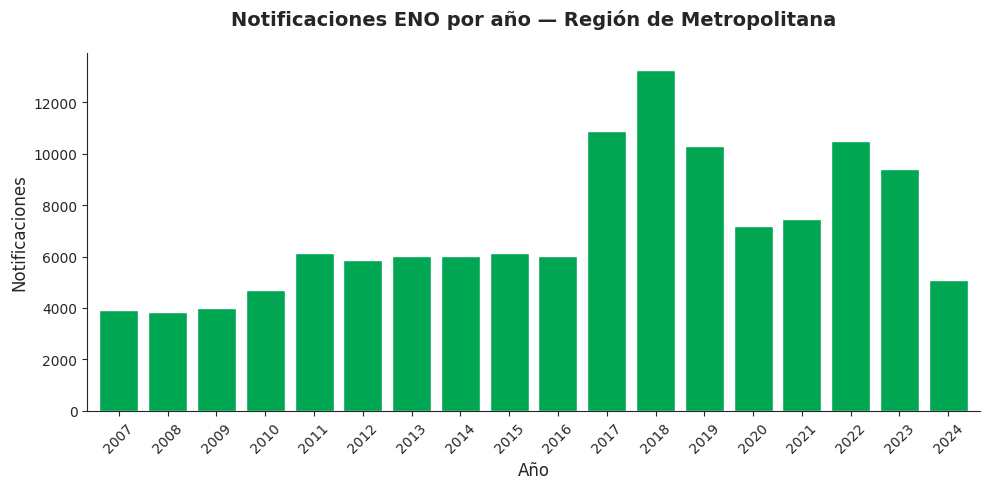

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtramos los datos
df_met = eno[eno['region'].str.contains("Metropolitana", na=False)]

# Configuraciones de estilo global
color_verde = "#00a651" # El verde de tus imágenes
sns.set_style("ticks")

# --- GRÁFICO 1: Notificaciones por Año ---
plt.figure(figsize=(10, 5))
datos_anho = df_met['anho_notificacion'].value_counts().sort_index()

ax1 = datos_anho.plot(kind='bar', color=color_verde, width=0.8)

plt.title("Notificaciones ENO por año — Región de Metropolitana", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Año", fontsize=12)
plt.ylabel("Notificaciones", fontsize=12)
plt.xticks(rotation=45)

# Quitar bordes superior y derecho
sns.despine()
plt.tight_layout()
plt.show()

2.4 Top 5

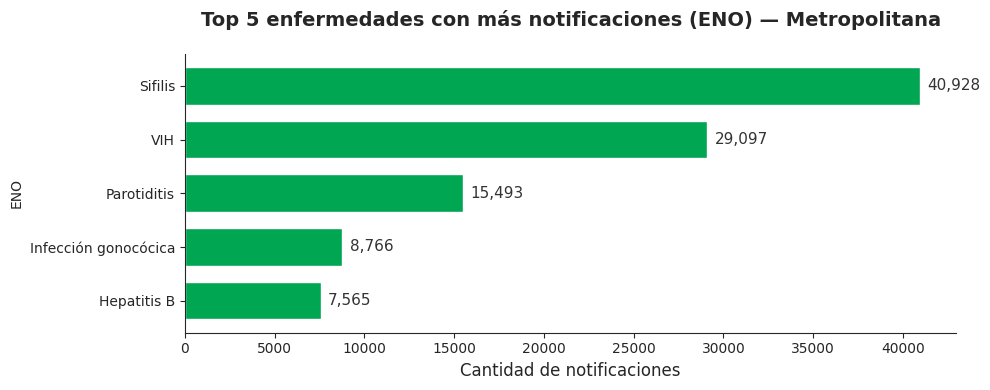

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtramos la base ENO para la región metropolitana
# (Usamos .str.contains por seguridad con los nombres largos)
eno_region = eno[eno['region'].str.contains("Metropolitana", na=False)].copy()

# 2. Calculamos las 5 enfermedades con más notificaciones (columna "ENO")
top_5_diseases = eno_region["ENO"].value_counts().head(5)

# 3. Configuramos el estilo y el color verde
plt.figure(figsize=(10, 4))
color_verde = "#00a651"
sns.set_style("ticks")

# 4. Creamos el gráfico de barras horizontales
ax = top_5_diseases.plot(kind='barh', color=color_verde, width=0.7)

# Títulos y etiquetas
plt.title("Top 5 enfermedades con más notificaciones (ENO) — Metropolitana",
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Cantidad de notificaciones", fontsize=12)
plt.gca().invert_yaxis() # Para que la más frecuente esté arriba

# Agregamos los números al final de cada barra
for i, v in enumerate(top_5_diseases):
    ax.text(v + (max(top_5_diseases)*0.01), i, f'{int(v):,}',
            va='center', fontsize=11, color='#333')

# Limpiamos el diseño
sns.despine()
plt.tight_layout()

# Mostramos el gráfico
plt.show()

2.5 Nacionalidad

In [37]:
eno_tar["nacionalidad"].value_counts()

,count
nacionalidad,
Desconocido,55863
Chile,47093
Extranjero,23713


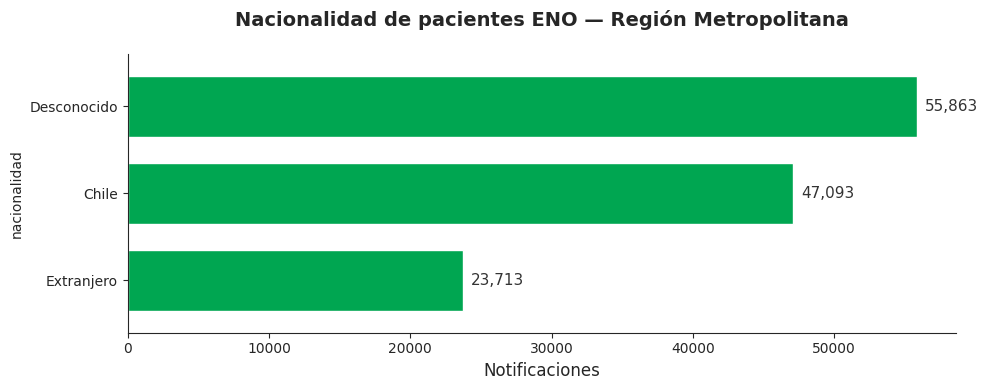

In [38]:
plt.figure(figsize=(10, 4))

datos_nac = df_mag['nacionalidad'].value_counts()

ax2 = datos_nac.plot(kind='barh', color=color_verde, width=0.7)

plt.title("Nacionalidad de pacientes ENO — Región Metropolitana", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Notificaciones", fontsize=12)
plt.gca().invert_yaxis() # Para que el más grande salga arriba

# Agregar etiquetas de números al final de las barras
for i, v in enumerate(datos_nac):
    ax2.text(v + (max(datos_nac)*0.01), i, f'{v:,}', color='#333', va='center', fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()

¿Cuál es la enfermedad más común en Magallanes para extranjeros?

In [39]:
eno_tar[eno_tar["nacionalidad"] == "Extranjero"] \
["ENO"].value_counts().head()

,count
ENO,
VIH,7974
Hepatitis B,6545
Sifilis,6202
Infección gonocócica,654
Parotiditis,544


¿Cuántas comunas únicas hay en ENO Metropolitana?

In [40]:
eno_tar["codigo_comuna_residencia"].nunique()

280

# **3. GRD**

3.1

In [61]:
import pandas as pd
import zipfile

cols = [
    "GLOSA_COMUNA_RESIDENCIA",
    "GLOSA_PAIS_ORIGEN",
    "GLOSA_REGION_RESIDENCIA",
    "SEXO",
    "DIAG1",
    "ANO_EGRESO",
    "DIAS_ESTADA"
]

ruta_zip = "/content/drive/MyDrive/Colab Notebooks/EGRESOS_2024.zip"

with zipfile.ZipFile(ruta_zip) as z:
    with z.open("EGRESOS_2024.csv") as f:
        grd = pd.read_csv(
            f,
            sep=";",
            usecols=cols,
            encoding="latin-1",
            low_memory=False
        )


print(f"Total registros cargados: {len(grd):,}")

Total registros cargados: 1,667,349


In [62]:
regiones = grd['GLOSA_REGION_RESIDENCIA'].unique()
print("Regiones encontradas:")
print(regiones)

print("\nCantidad de registros por región:")
print(grd['GLOSA_REGION_RESIDENCIA'].value_counts())

Regiones encontradas:
['De Tarapacá' 'De Antofagasta' 'De Atacama' 'De Coquimbo' 'De Valparaíso'
 "Del Libertador B. O'Higgins" 'Del Maule' 'Del Bíobío' 'De La Araucanía'
 'De Los Lagos' 'De Aisén del Gral. C. Ibáñez del Campo'
 'De Magallanes y de La Antártica Chilena' 'Metropolitana de Santiago'
 'De Los Ríos' 'De Arica y Parinacota' 'De Ñuble' 'Extranjero' 'Ignorada'
 '*']

Cantidad de registros por región:
GLOSA_REGION_RESIDENCIA
Metropolitana de Santiago                  648390
De Valparaíso                              166279
Del Bíobío                                 166268
De La Araucanía                             92569
Del Maule                                   89879
De Los Lagos                                84604
Del Libertador B. O'Higgins                 75579
De Antofagasta                              57800
De Coquimbo                                 56230
De Ñuble                                    45322
De Los Ríos                                 40499
De Tarapacá 

3.2


In [63]:
mi_region = "Metropolitana de Santiago"

# Filtramos
grd_region = grd[grd['GLOSA_REGION_RESIDENCIA'] == mi_region].copy()

total_egresos = len(grd_region)

print(f"Total de egresados en Metropolitana de Santiago: {total_egresos:,}")

Total de egresados en Metropolitana de Santiago: 648,390


3.3

In [67]:
import pandas as pd
import zipfile

with zipfile.ZipFile(ruta_zip) as z:
    with z.open("Diccionario BD egresos hospitalario.xlsx") as f:
        cie10 = pd.read_excel(f, sheet_name="codigo CIE-10", header=8)

cie10.columns = cie10.columns.str.strip()

columnas_a_borrar = ["CODIGO SUBCATEGORIA", "GLOSA CATEGORIA"]
grd = grd.drop(columns=[c for c in columnas_a_borrar if c in grd.columns])

cie10_clean = cie10[["CODIGO SUBCATEGORIA", "GLOSA CATEGORIA"]].rename(
    columns={"CODIGO SUBCATEGORIA": "DIAG1"}
)

grd = grd.merge(cie10_clean, on="DIAG1", how="left")

print("Unión completada exitosamente.")
display(grd[["DIAG1", "GLOSA CATEGORIA"]].head())

Unión completada exitosamente.


,DIAG1,GLOSA CATEGORIA
0,N908,Otros trastornos no inflamatorios de la vulva ...
1,O680,Trabajo de parto y parto complicados por sufri...
2,O757,Otras complicaciones del trabajo de parto y de...
3,N800,Endometriosis
4,O601,Parto prematuro


3.4 Top 5

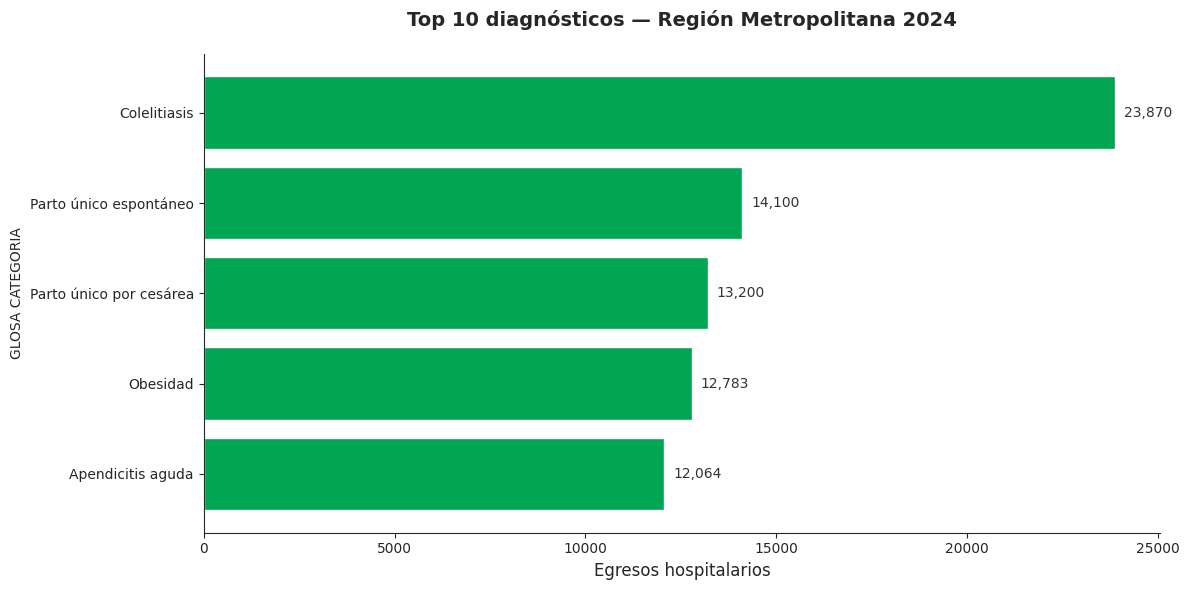

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

grd_region = grd[grd['GLOSA_REGION_RESIDENCIA'].str.contains("Metropolitana", na=False)].copy()

top_10_diag = grd_region["GLOSA CATEGORIA"].value_counts().head(5)

plt.figure(figsize=(12, 6))
color_verde = "#00a651"
sns.set_style("ticks")

ax = top_10_diag.plot(kind='barh', color=color_verde, width=0.8)

plt.title("Top 10 diagnósticos — Región Metropolitana 2024", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Egresos hospitalarios", fontsize=12)
plt.gca().invert_yaxis()

for i, v in enumerate(top_10_diag):
    ax.text(v + (max(top_10_diag)*0.01), i, f'{int(v):,}',
            va='center', fontsize=10, color='#333')

sns.despine()
plt.tight_layout()

plt.show()